In [1]:
import duckdb
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
project_root_path = "../../"
customers_path = project_root_path + "data/customers.parquet"

In [3]:
# Load customers table
customers = duckdb.read_parquet(customers_path)

# Sales
purchase = duckdb.sql("SELECT * FROM customers WHERE event_type = 'purchase'")

In [4]:
# Number of orders and total money spent per customer
metrics = duckdb.sql(
"""
SELECT
    user_id,
    COUNT(DISTINCT user_session) AS nb_orders,
    SUM(price) AS total_spent
FROM
    purchase
GROUP BY
    user_id
ORDER BY nb_orders DESC, total_spent DESC
"""
).df()

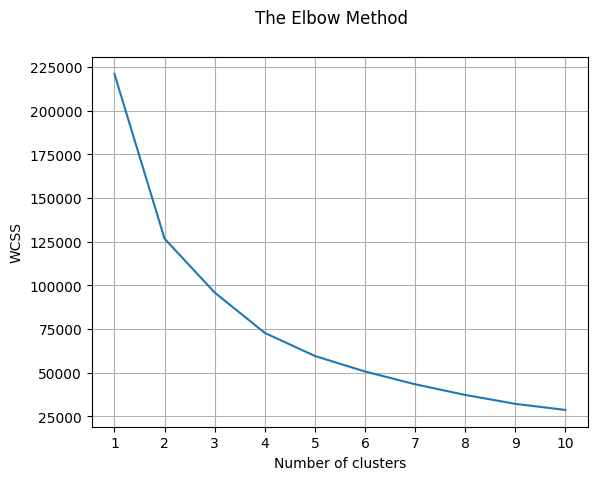

In [5]:
nb_clusters = range(1, 11)
wcss = []

for i in nb_clusters:
  matrix = metrics[['nb_orders', 'total_spent']].to_numpy()
  scaler = StandardScaler()
  x_scaled = scaler.fit_transform(matrix)
  kmeans=KMeans(n_clusters=i, n_init=42)
  kmeans.fit_predict(x_scaled)
  wcss.append(kmeans.inertia_)

fig, ax = plt.subplots()

fig.suptitle('The Elbow Method')

ax.plot(nb_clusters, wcss)

# wcss_diff = [wcss[i + 1] - wcss[i] + wcss[0] for i in range(0, len(wcss) - 1)]
# wcss_diff.insert(0, wcss[0])

# ax.plot(nb_clusters, wcss_diff)


ax.set_xlabel('Number of clusters')
ax.set_xticks(nb_clusters)
ax.set_ylabel('WCSS')
ax.grid()

plt.show()